In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [2]:
df = pd.read_parquet('/scratch/mk27/mj8805/comb.parquet')
df.head()

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,F(5.8),e_F(5.8),F(8.0),e_F(8.0),q_3.6mag,q_4.5mag,q_5.8mag,q_8.0mag,in_vvv,in_glimpse
0,103811983,,-1,5886890331526270336,47081231,178611,gaia_dr3_source,31,63050396146720660,5536627798,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False
1,103714167,,-1,5883385019721613440,47300399,180097,gaia_dr3_source,31,63050396142473249,5538808743,...,47.150002,1.621,26.540001,0.8183,00104040,00000000,00000000,00000000,False,True
2,103718625,,-1,5883554207064432896,284644795,180100,gaia_dr3_source,31,63050396142590129,5539204456,...,28.469999,1.152,16.340000,0.5626,00004000,00000000,00000000,00000000,False,True
3,103774799,,-1,5885400630694863872,285893955,178233,gaia_dr3_source,31,63050396144891037,5537764156,...,30.730000,1.177,16.850000,0.4562,00000140,000840c0,00000000,00008000,True,True
4,103769763,,-1,5885180655340639616,285817227,178992,gaia_dr3_source,31,63050396144755158,5537822117,...,25.940001,1.067,13.490000,0.3912,00000040,00000000,00000000,00000000,True,True


In [3]:
len(df)

19533

In [4]:
vvv = df[df['in_vvv']]
len(vvv)

5487

In [5]:
vvv.columns

Index(['sdss_id', 'sdss4_apogee_id', 'gaia_dr2_source_id',
       'gaia_dr3_source_id', 'tic_v8_id', 'healpix', 'lead', 'version_id',
       'catalogid', 'catalogid21',
       ...
       'F(5.8)', 'e_F(5.8)', 'F(8.0)', 'e_F(8.0)', 'q_3.6mag', 'q_4.5mag',
       'q_5.8mag', 'q_8.0mag', 'in_vvv', 'in_glimpse'],
      dtype='str', length=503)

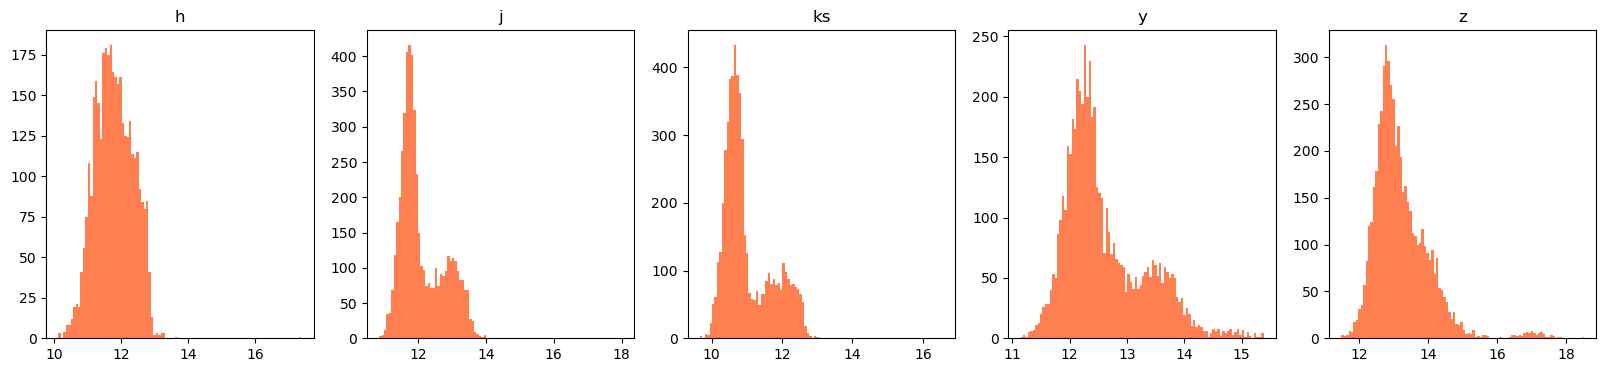

In [6]:
FILTERS = ['h', 'j', 'ks', 'y', 'z']
fig, ax = plt.subplots(nrows=1, ncols=len(FILTERS), figsize=(len(FILTERS)*4, 4))
for i, f in enumerate(FILTERS):
    ax[i].hist(vvv['phot_'+f+'_mean_mag'], bins=100, color='coral');
    ax[i].set_title(f);

In [7]:
from mw_plot import MWSkyMap
mw = MWSkyMap()

In [8]:
import astropy.units as u

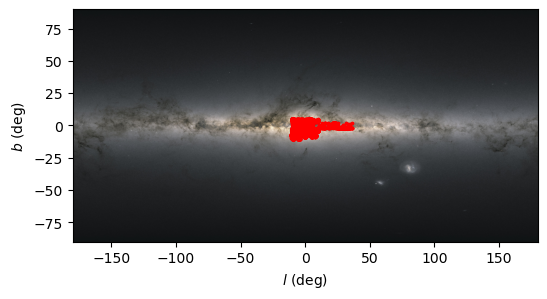

In [9]:
mw.scatter(vvv['ra'].values * u.degree, vvv['dec'].values * u.degree, c="r", s=3)

In [10]:
glimpse = df[df['in_glimpse']]
len(glimpse)

15972

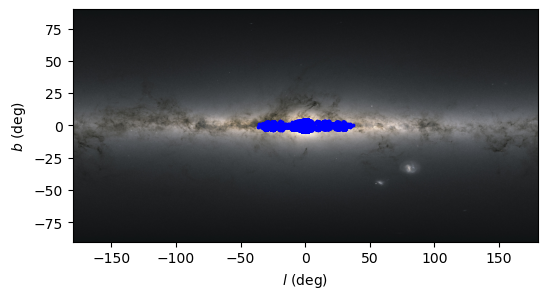

In [11]:
mw = MWSkyMap()
mw.scatter(glimpse['ra'].values * u.degree, glimpse['dec'].values * u.degree, c="b", s=3)
plt.show()

In [12]:
list(glimpse.columns)

['sdss_id',
 'sdss4_apogee_id',
 'gaia_dr2_source_id',
 'gaia_dr3_source_id',
 'tic_v8_id',
 'healpix',
 'lead',
 'version_id',
 'catalogid',
 'catalogid21',
 'catalogid25',
 'catalogid31',
 'n_associated',
 'n_neighborhood',
 'crossmatch_flags',
 'sdss4_apogee_target1_flags',
 'sdss4_apogee_target2_flags',
 'sdss4_apogee2_target1_flags',
 'sdss4_apogee2_target2_flags',
 'sdss4_apogee2_target3_flags',
 'sdss4_apogee_member_flags',
 'sdss4_apogee_extra_target_flags',
 'ra',
 'dec',
 'l',
 'b',
 'plx',
 'e_plx',
 'pmra',
 'e_pmra',
 'pmde',
 'e_pmde',
 'gaia_v_rad',
 'gaia_e_v_rad',
 'g_mag',
 'bp_mag',
 'rp_mag',
 'j_mag',
 'e_j_mag',
 'h_mag',
 'e_h_mag',
 'k_mag',
 'e_k_mag',
 'ph_qual',
 'bl_flg',
 'cc_flg',
 'w1_mag',
 'e_w1_mag',
 'w1_flux',
 'w1_dflux',
 'w1_frac',
 'w2_mag',
 'e_w2_mag',
 'w2_flux',
 'w2_dflux',
 'w2_frac',
 'w1uflags',
 'w2uflags',
 'w1aflags',
 'w2aflags',
 'mag4_5',
 'd4_5m',
 'rms_f4_5',
 'sqf_4_5',
 'mf4_5',
 'csf',
 'zgr_teff',
 'zgr_e_teff',
 'zgr_logg',
 

In [33]:
labels_to_plot = ['raw_teff', 'raw_logg', 'raw_fe_h',
                  'raw_c_h', 'raw_n_h', 'raw_o_h', 'raw_na_h', 'raw_mg_h',
                  'raw_si_h', 'raw_s_h', 'raw_ca_h', 'raw_ti_h', 'raw_cr_h',
                  'raw_ni_h', 'raw_cu_h', 'raw_ce_h']

In [34]:
def plot_sigma_hist(data, col, bins=100, sigma=3, ax=None, **kwargs):
    """
    Plots a histogram of values in `data[col]` within `sigma` standard deviations from the mean.

    Parameters:
    - data: pandas DataFrame
    - col: column name (str)
    - bins: number of bins for the histogram
    - sigma: number of standard deviations for cutoff
    - ax: matplotlib Axes to plot into (optional)
    - kwargs: any additional arguments for ax.hist or plt.hist
    """
    values = data[col].dropna()
    mu = values.mean()
    std = values.std()
    mask = (values > mu - sigma*std) & (values < mu + sigma*std)
    if ax is None:
        fig, ax = plt.subplots()
        created_ax = True
    else:
        created_ax = False
    ax.hist(values[mask], bins=bins, **kwargs)
    ax.set_title(f"{col} within {sigma}σ")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    if created_ax:
        plt.show()

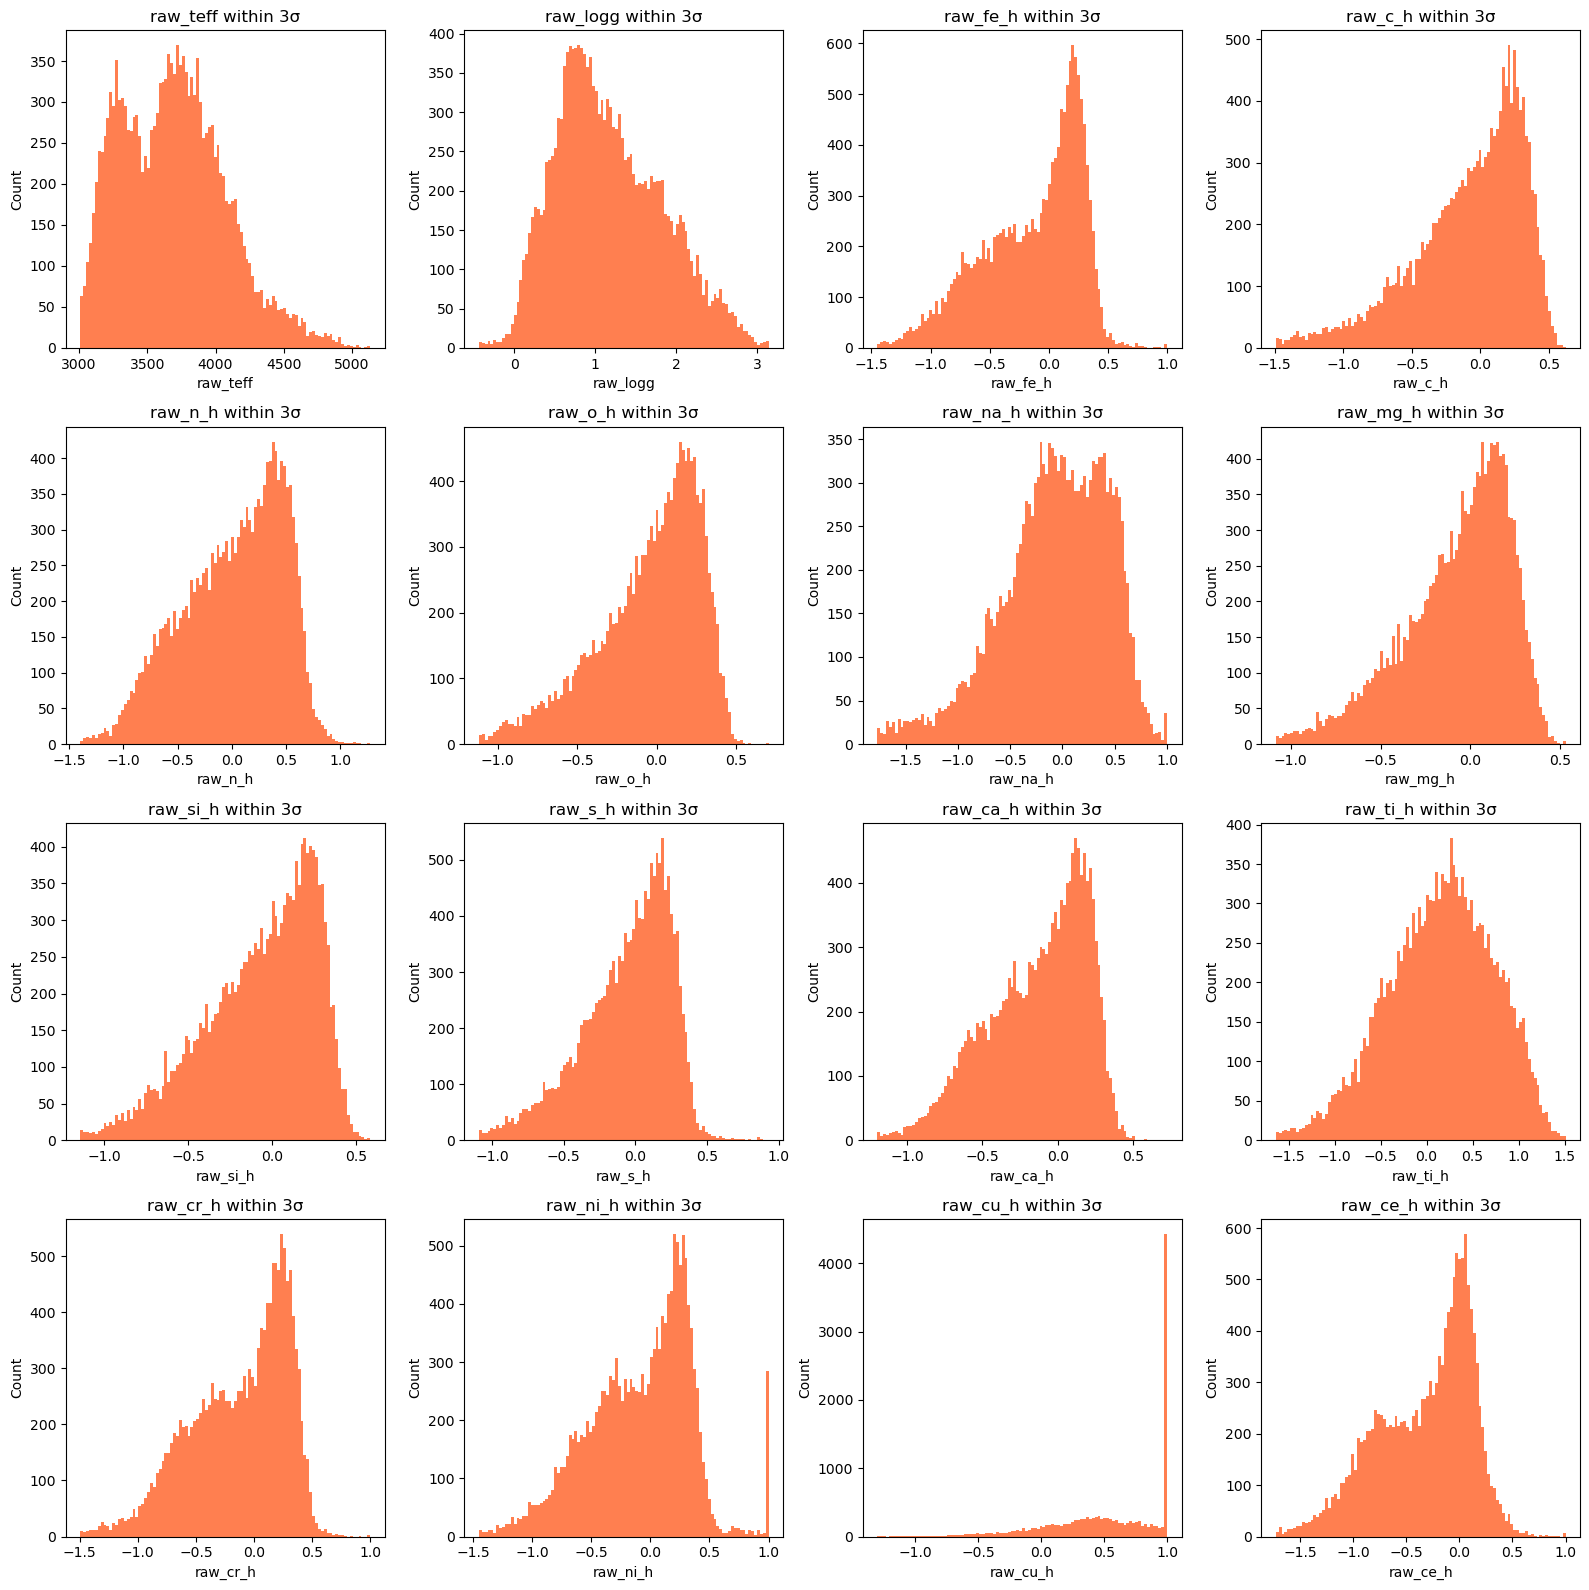

In [35]:
fig, ax = plt.subplots(4, 4, figsize=(16, 16))
for i, col in enumerate(labels_to_plot):
    plot_sigma_hist(glimpse, col, color='coral', ax=ax[i//4, i%4])
plt.tight_layout()
plt.show()
